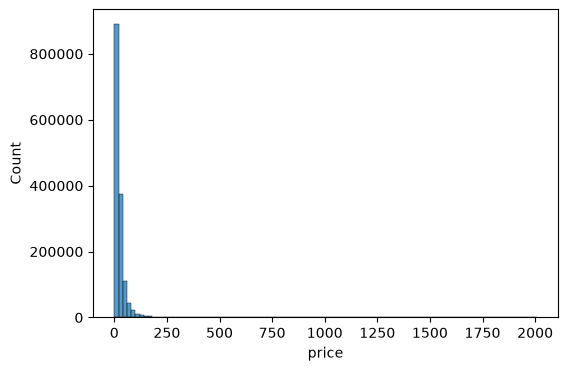

전처리 전 : (1482535, 8)
가격 이상치(0원 이하 / 2000달러 초과) 제거 후 : (1481658, 8)
train_id 제거 및 중복 제거 후 : (1481609, 7)


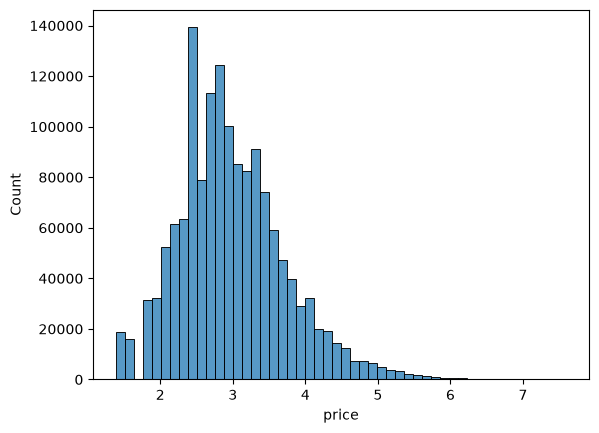

In [40]:
#데이터 불러오기

from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import pickle

RANDOM_STATE = 42  # 재현성을 위해 랜덤값 고정

mercari_df = pd.read_csv('../../data/mercari_train.tsv', sep='\t')

# 가격 분포 확인
y_labels = mercari_df['price']
plt.figure(figsize=(6, 4))
sns.histplot(y_labels, bins=100)
plt.show()

mercari_df.value_counts('price').sort_index()

# 가격 이상치 처리
# 1) 0원 이하: 무효 데이터라 제거
# 2) 2000달러 초과: Mercari 플랫폼의 실제 최대 등록가 정책(도메인 규칙) 기준 제거 - 0원 처리와 동일한 원칙
print(f'전처리 전 : {mercari_df.shape}')

mercari_df = mercari_df[(mercari_df['price'] > 0) & (mercari_df['price'] <= 2000)]
print(f'가격 이상치(0원 이하 / 2000달러 초과) 제거 후 : {mercari_df.shape}')

# train_id 컬럼 제거 + 중복 제거
mercari_df.drop(columns='train_id', inplace=True)
mercari_df = mercari_df.drop_duplicates()
mercari_df = mercari_df.reset_index(drop=True)
print(f'train_id 제거 및 중복 제거 후 : {mercari_df.shape}')

# 가격 로그 변환 (분포가 크게 치우쳐 있어 log1p 적용, 예측 후 expm1로 원래 스케일 복원 예정)
y_labels = mercari_df['price']
mercari_df['price'] = np.log1p(y_labels)
y_labels = np.log1p(y_labels)

sns.histplot(y_labels, bins=50)
plt.show()

In [41]:
mercari_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1481609 entries, 0 to 1481608
Data columns (total 7 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   name               1481609 non-null  str    
 1   item_condition_id  1481609 non-null  int64  
 2   category_name      1475295 non-null  str    
 3   brand_name         849314 non-null   str    
 4   price              1481609 non-null  float64
 5   shipping           1481609 non-null  int64  
 6   item_description   1481603 non-null  str    
dtypes: float64(1), int64(2), str(4)
memory usage: 79.1 MB


In [42]:
# category_name 3단계 분리 (Main/Sub/SubSub) - 구조적 파싱이라 split 이전에 해도 leakage 없음
def split_category(df, col='category_name'):
    df = df.copy()
    df[col] = df[col].fillna('Unknown/Unknown/Unknown')
    parts = df[col].str.split('/', n=2, expand=True)
    parts.columns = ['cat_main', 'cat_sub', 'cat_sub2']
    parts = parts.fillna('Unknown')  # 3단계가 안 나온 행 보정
    return pd.concat([df, parts], axis=1)

mercari_df = split_category(mercari_df)
mercari_df[['category_name', 'cat_main', 'cat_sub', 'cat_sub2']].head()

,category_name,cat_main,cat_sub,cat_sub2
0,Men/Tops/T-shirts,Men,Tops,T-shirts
1,Electronics/Computers & Tablets/Components & P...,Electronics,Computers & Tablets,Components & Parts
2,Women/Tops & Blouses/Blouse,Women,Tops & Blouses,Blouse
3,Home/Home Décor/Home Décor Accents,Home,Home Décor,Home Décor Accents
4,Women/Jewelry/Necklaces,Women,Jewelry,Necklaces


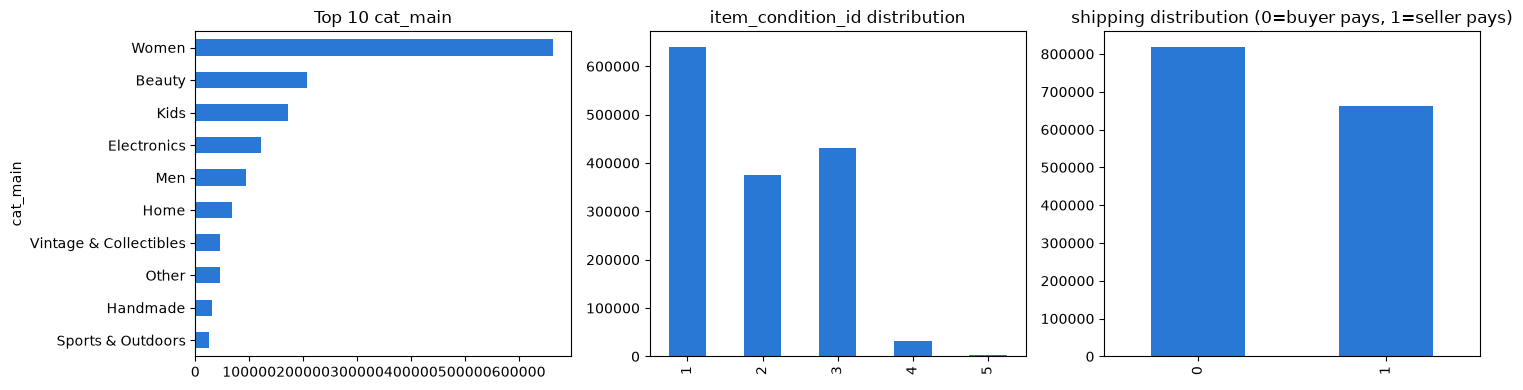

In [43]:
# 데이터 특성 시각화 - 카테고리 대분류 / item_condition_id / shipping 분포
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

mercari_df['cat_main'].value_counts().head(10).plot(kind='barh', ax=axes[0], color='#2a78d6')
axes[0].invert_yaxis()
axes[0].set_title('Top 10 cat_main')

mercari_df['item_condition_id'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='#2a78d6')
axes[1].set_title('item_condition_id distribution')
axes[1].set_xlabel('')

mercari_df['shipping'].value_counts().sort_index().plot(kind='bar', ax=axes[2], color='#2a78d6')
axes[2].set_title('shipping distribution (0=buyer pays, 1=seller pays)')
axes[2].set_xlabel('')

plt.tight_layout()
plt.show()

In [44]:
# 학습 / 테스트 데이터 분리
# 실제 test.tsv(정답 없는 제출용)가 아니라, 보유한 train 데이터를 직접 나눠서 검증에 사용한다.
# 이 시점 이후의 모든 "학습(fit)" 단계는 train_df에서만 수행하고 test_df에는 적용(transform)만 한다.
train_df, test_df = train_test_split(
    mercari_df, test_size=0.2, random_state=RANDOM_STATE
)
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f'train_df : {train_df.shape}')
print(f'test_df  : {test_df.shape}')

train_df : (1185287, 10)
test_df  : (296322, 10)


In [45]:
# brand_name 결측치 채우기 - item_description에서 브랜드명 매칭
# 주의: 아직 item_description을 불용어 제거/토큰화하기 전(원문에 가까운 상태)에 매칭해야
#       "Kate Spade"처럼 여러 단어로 된 브랜드명이나 특수문자가 포함된 브랜드명이 깨지지 않는다.

def build_known_brands(df, col='brand_name'):
    """train 데이터에서만 호출해야 함 - 이미 채워진 값들로 알려진 브랜드 목록 생성"""
    return sorted(df[col].dropna().unique().tolist())

def build_brand_pattern(known_brands):
    """긴 브랜드명이 먼저 매칭되도록 길이 내림차순 정렬 + 단어 경계(\\b) 정규식 컴파일"""
    sorted_brands = sorted([b for b in known_brands if len(b) > 0], key=len, reverse=True)
    escaped = [re.escape(b.lower()) for b in sorted_brands]
    pattern = re.compile(r'\b(' + '|'.join(escaped) + r')\b')
    lower_to_original = {b.lower(): b for b in sorted_brands}
    return pattern, lower_to_original

def fill_brand_from_description(df, pattern, lower_to_original,
                                 desc_col='item_description', brand_col='brand_name'):
    """brand_col이 NaN인 행에 대해서만 desc_col에서 브랜드를 탐색해 채운다."""
    df = df.copy()
    missing_mask = df[brand_col].isna()

    def find_brand(text):
        match = pattern.search(str(text).lower())
        if match:
            return lower_to_original[match.group(1)]
        return None

    found = df.loc[missing_mask, desc_col].fillna('').apply(find_brand)
    df.loc[missing_mask, brand_col] = found
    return df

# 1) train에서만 브랜드 사전 생성 (leakage 방지)
known_brands = build_known_brands(train_df)
brand_pattern, brand_lower_to_original = build_brand_pattern(known_brands)
print(f'train 기준 알려진 브랜드 수 : {len(known_brands)}')

# 2) train의 결측 brand_name을 description 매칭으로 채우기
train_df = fill_brand_from_description(train_df, brand_pattern, brand_lower_to_original)

# 3) 사전을 파일로 저장해두고 test/향후 데이터에는 이 파일을 불러와 "적용만" 한다
with open('brand_dictionary.pkl', 'wb') as f:
    pickle.dump(known_brands, f)

train 기준 알려진 브랜드 수 : 4535


In [46]:
# test_df에는 train에서 만든 사전을 "적용만" 한다 (사전을 새로 만들지 않음)
test_df = fill_brand_from_description(test_df, brand_pattern, brand_lower_to_original)

# train 사전에 없는 브랜드는 test에서 원래 값으로 존재했든 description 매칭으로 채워졌든
# 전부 'Unknown'으로 통일한다 (인코딩 단계의 unseen category 문제 방지)
known_brands_set = set(known_brands)

def restrict_to_known(series, known_set, unknown_value='Unknown'):
    return series.where(series.isin(known_set) & series.notna(), unknown_value)

train_df['brand_name'] = restrict_to_known(train_df['brand_name'], known_brands_set)
test_df['brand_name'] = restrict_to_known(test_df['brand_name'], known_brands_set)

# category_name도 동일한 원칙 적용: train에 등장한 조합만 known set으로 인정
for col in ['cat_main', 'cat_sub', 'cat_sub2']:
    known_cats = set(train_df[col].unique())
    test_df[col] = restrict_to_known(test_df[col], known_cats)

print('brand_name 결측치 (train):', train_df['brand_name'].isna().sum())
print('brand_name 결측치 (test) :', test_df['brand_name'].isna().sum())
print(train_df['brand_name'].value_counts().head())

brand_name 결측치 (train): 0
brand_name 결측치 (test) : 0
brand_name
Unknown              196041
AND                   99396
PINK                  55325
Nike                  43972
Victoria's Secret     39366
Name: count, dtype: int64


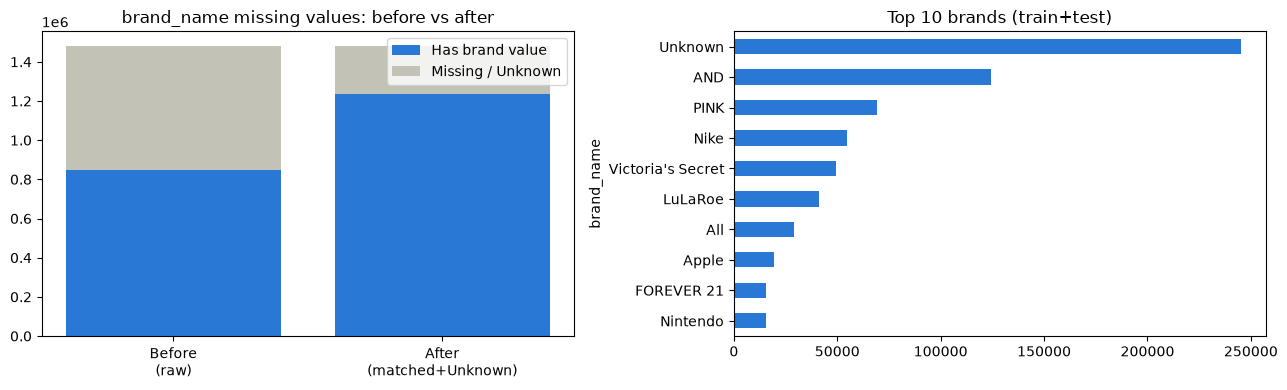

In [47]:
# brand_name 결측치 처리 결과 시각화
before_missing = mercari_df['brand_name'].isna().sum()
before_present = len(mercari_df) - before_missing

after_unknown = (train_df['brand_name'] == 'Unknown').sum() + (test_df['brand_name'] == 'Unknown').sum()
after_identified = len(train_df) + len(test_df) - after_unknown

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(['Before\n(raw)', 'After\n(matched+Unknown)'], [before_present, after_identified],
            color='#2a78d6', label='Has brand value')
axes[0].bar(['Before\n(raw)', 'After\n(matched+Unknown)'], [before_missing, after_unknown],
            bottom=[before_present, after_identified], color='#c3c2b7', label='Missing / Unknown')
axes[0].set_title('brand_name missing values: before vs after')
axes[0].legend()

top_brands = pd.concat([train_df['brand_name'], test_df['brand_name']]).value_counts().head(10)
top_brands.plot(kind='barh', ax=axes[1], color='#2a78d6')
axes[1].invert_yaxis()
axes[1].set_title('Top 10 brands (train+test)')

plt.tight_layout()
plt.show()

In [48]:
# 텍스트 전처리 유틸 함수 (item_description, name 공통 사용)
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

def text_cleaning(text):
    # 소문자로 변환
    text = text.lower()
    # 영문자/숫자/공백을 제외한 문자 제거 ([rm] 마스킹 토큰의 대괄호도 여기서 제거됨)
    # 숫자는 제거하지 않음 - 4gb, 32gb, 사이즈 등 가격에 영향을 줄 수 있는 정보라 보존
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    # 여러 개의 공백을 하나로 변경
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

# 불용어 세팅
stop_words = set(stopwords.words('english'))

# 제거하면 안 되는 부정 표현
# (버그 수정: 기존 코드는 'never'와 'without' 사이에 콤마가 빠져 있어서
#  파이썬이 두 문자열을 'neverwithout' 하나로 합쳐버렸음 -> 콤마 추가로 수정)
negative_words = {
    'no',
    'not',
    'nor',
    'never',
    'without'
}
stop_words = stop_words - negative_words

# [rm] 마스킹 토큰이 클렌징 후 'rm'이라는 의미 없는 잔여 토큰으로 남는 것을 불용어로 추가 제거
stop_words = stop_words | {'rm'}

def preprocess_text(text):
    # 1. 소문자 / 영문자 / 숫자 / 공백 정리
    text = text_cleaning(text)
    # 2. 단어 단위 토큰화
    tokens = word_tokenize(text)
    # 3. 불용어 제거
    tokens = [word for word in tokens if word not in stop_words]
    return tokens

In [49]:
# item_description, name 클렌징 적용 (train_df, test_df 각각에 동일하게 적용 - 순수 per-row 변환이라 leakage 없음)
# 데이터 규모가 커서 시간이 다소 걸릴 수 있음 (수 분 단위)

def clean_text_columns(df):
    df = df.copy()
    df['item_description'] = df['item_description'].fillna('No description yet').astype(str)
    df['name'] = df['name'].fillna('').astype(str)

    df['item_description'] = df['item_description'].apply(preprocess_text).apply(lambda x: ' '.join(x))
    df['name'] = df['name'].apply(preprocess_text).apply(lambda x: ' '.join(x))
    return df

train_df = clean_text_columns(train_df)
test_df = clean_text_columns(test_df)

train_df[['name', 'item_description']].head()

,name,item_description
0,forever 21 sundress,nwts forever 21 purple sundress shoulder size
1,bundle pants,bundle pants good condition except green ones ...
2,peach shirt free ship,size medium plain 3 4 sleeve peach colored top...
3,bundle kalislp,item worn no holes tears minor pulls
4,new bikini lot 2 sz sm free shipping,awesome brazilian bikinis one black one teal s...


In [50]:
# item_description / name 텍스트 벡터화 (TfidfVectorizer)
# 원칙: train으로만 fit(), test는 transform()만 - 새 단어는 에러 없이 그냥 무시됨
name_vectorizer = TfidfVectorizer(max_features=30000, ngram_range=(1, 2))
desc_vectorizer = TfidfVectorizer(max_features=50000, ngram_range=(1, 2))

X_name_train = name_vectorizer.fit_transform(train_df['name'])
X_name_test = name_vectorizer.transform(test_df['name'])

X_desc_train = desc_vectorizer.fit_transform(train_df['item_description'])
X_desc_test = desc_vectorizer.transform(test_df['item_description'])

print('name 벡터 shape       :', X_name_train.shape, X_name_test.shape)
print('description 벡터 shape:', X_desc_train.shape, X_desc_test.shape)

# 벡터라이저 객체 저장 (brand 사전과 동일한 관리 방식 - 재사용을 위해 fit된 객체 자체를 보존)
with open('name_vectorizer.pkl', 'wb') as f:
    pickle.dump(name_vectorizer, f)
with open('desc_vectorizer.pkl', 'wb') as f:
    pickle.dump(desc_vectorizer, f)

name 벡터 shape       : (1185287, 30000) (296322, 30000)
description 벡터 shape: (1185287, 50000) (296322, 50000)


In [51]:
# brand_name / category 원-핫 인코딩
# handle_unknown='ignore' -> train에 없던 값이 test에 나와도 에러 없이 전부 0벡터로 처리됨
# (이미 restrict_to_known으로 'Unknown' 통일까지 해뒀지만, 이중 안전장치로 추가)
from sklearn.preprocessing import OneHotEncoder

cat_cols = ['brand_name', 'cat_main', 'cat_sub', 'cat_sub2']

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
X_cat_train = ohe.fit_transform(train_df[cat_cols])
X_cat_test = ohe.transform(test_df[cat_cols])

print('카테고리 원-핫 shape :', X_cat_train.shape, X_cat_test.shape)

with open('cat_encoder.pkl', 'wb') as f:
    pickle.dump(ohe, f)

카테고리 원-핫 shape : (1185287, 5527) (296322, 5527)


In [52]:
# 수치형 피처 스케일링 (item_condition_id)
# GBM은 스케일에 둔감하지만 베이스라인 선형회귀(Ridge)를 위해 표준화한다.
# shipping은 이미 0/1 이진값이라 스케일링 대상에서 제외.
numeric_cols = ['item_condition_id']

scaler = StandardScaler()
X_num_train = scaler.fit_transform(train_df[numeric_cols])
X_num_test = scaler.transform(test_df[numeric_cols])

print('수치형 스케일링 shape :', X_num_train.shape, X_num_test.shape)

with open('numeric_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

수치형 스케일링 shape : (1185287, 1) (296322, 1)


In [53]:
# 최종 feature 결합 + 전체 전처리 파이프라인을 하나로 묶기
from scipy.sparse import csr_matrix, hstack

def combine_features(X_cat, X_num, shipping_series, X_name, X_desc):
    X_ship = csr_matrix(shipping_series.values.reshape(-1, 1))
    return hstack([X_cat, X_num, X_ship, X_name, X_desc]).tocsr()

X_train = combine_features(X_cat_train, X_num_train, train_df['shipping'], X_name_train, X_desc_train)
X_test = combine_features(X_cat_test, X_num_test, test_df['shipping'], X_name_test, X_desc_test)

y_train = train_df['price'].values  # 이미 log1p 적용된 값
y_test = test_df['price'].values

print('X_train :', X_train.shape, ' X_test :', X_test.shape)

# 학습 때 사용한 모든 전처리 객체를 하나의 아티팩트로 묶어서 저장한다.
# -> 이후 새 상품 하나(또는 새 데이터셋)가 들어와도 이 파일 하나만 불러와서
#    preprocess_new_data()에 통과시키면 학습 때와 완전히 동일한 형식의 feature가 나온다.
pipeline_artifacts = {
    'known_brands': known_brands,
    'brand_pattern': brand_pattern,
    'brand_lower_to_original': brand_lower_to_original,
    'known_brands_set': known_brands_set,
    'known_cats': {col: set(train_df[col].unique()) for col in cat_cols},
    'stop_words': stop_words,
    'cat_encoder': ohe,
    'numeric_scaler': scaler,
    'name_vectorizer': name_vectorizer,
    'desc_vectorizer': desc_vectorizer,
    'numeric_cols': numeric_cols,
    'cat_cols': cat_cols,
}

with open('mercari_pipeline.pkl', 'wb') as f:
    pickle.dump(pipeline_artifacts, f)


def preprocess_new_data(raw_df, artifacts=pipeline_artifacts):
    """새로 들어온 원본 데이터(raw_df)에 학습 때와 동일한 전처리를 그대로 적용해
    모델 입력용 희소행렬을 반환한다. (train 재학습 없이 저장된 아티팩트만 사용)"""
    df = raw_df.copy()

    # 1) category 3분할
    df = split_category(df)

    # 2) brand_name 결측치 채우기 (원문 description 기준 매칭)
    df = fill_brand_from_description(df, artifacts['brand_pattern'], artifacts['brand_lower_to_original'])
    df['brand_name'] = restrict_to_known(df['brand_name'], artifacts['known_brands_set'])
    for col in ['cat_main', 'cat_sub', 'cat_sub2']:
        df[col] = restrict_to_known(df[col], artifacts['known_cats'][col])

    # 3) 텍스트 클렌징 (name, item_description)
    df = clean_text_columns(df)

    # 4) 인코딩 / 벡터화 / 스케일링 (전부 transform만 수행)
    X_cat = artifacts['cat_encoder'].transform(df[artifacts['cat_cols']])
    X_num = artifacts['numeric_scaler'].transform(df[artifacts['numeric_cols']])
    X_name = artifacts['name_vectorizer'].transform(df['name'])
    X_desc = artifacts['desc_vectorizer'].transform(df['item_description'])

    return combine_features(X_cat, X_num, df['shipping'], X_name, X_desc)

X_train : (1185287, 85529)  X_test : (296322, 85529)


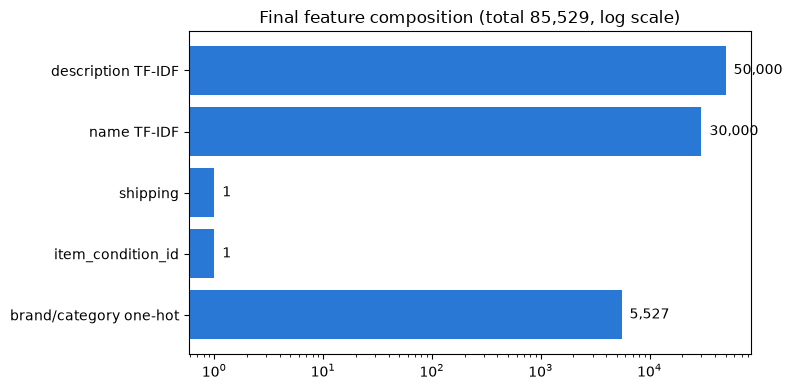

In [54]:
# feature 구성 비율 시각화
feature_sizes = {
    'brand/category one-hot': X_cat_train.shape[1],
    'item_condition_id': X_num_train.shape[1],
    'shipping': 1,
    'name TF-IDF': X_name_train.shape[1],
    'description TF-IDF': X_desc_train.shape[1],
}

plt.figure(figsize=(8, 4))
bars = plt.barh(list(feature_sizes.keys()), list(feature_sizes.values()), color='#2a78d6')
plt.xscale('log')
plt.title(f'Final feature composition (total {X_train.shape[1]:,}, log scale)')
for b, v in zip(bars, feature_sizes.values()):
    plt.text(v, b.get_y()+b.get_height()/2, f'  {v:,}', va='center')
plt.tight_layout()
plt.show()

In [55]:
# 평가지표: RMSLE
# y_train/y_test가 이미 log1p(price)이므로, 로그 스케일에서의 RMSE가 곧 RMSLE와 수학적으로 동일하다.
# rmsle(price_pred, price_true) = sqrt(mean((log1p(price_pred)-log1p(price_true))^2))
#                                = sqrt(mean((pred_log - true_log)^2))  <- 이미 log1p된 값끼리 비교
from sklearn.metrics import mean_squared_error

def rmsle_on_log_scale(y_true_log, y_pred_log):
    return np.sqrt(mean_squared_error(y_true_log, y_pred_log))

In [56]:
# 베이스라인 모델: Ridge 회귀
# feature가 85,529개라 과적합 방지용으로 L2 정규화가 있는 Ridge 사용
ridge = Ridge(alpha=1.0)  # alpha: 정규화 강도

ridge.fit(X_train, y_train)  # 계수 학습

ridge_pred = ridge.predict(X_test)  # 예측값 (아직 log1p 스케일)

ridge_rmsle = rmsle_on_log_scale(y_test, ridge_pred)  # log 스케일 RMSE = RMSLE

print(f'[Ridge baseline] RMSLE : {ridge_rmsle:.5f}')  # GBM과 비교할 기준점

[Ridge baseline] RMSLE : 0.45597


       version  ridge_rmsle
digits removed     0.458920
   digits kept     0.455966
차이: -0.00295  (digits kept가 더 좋음)


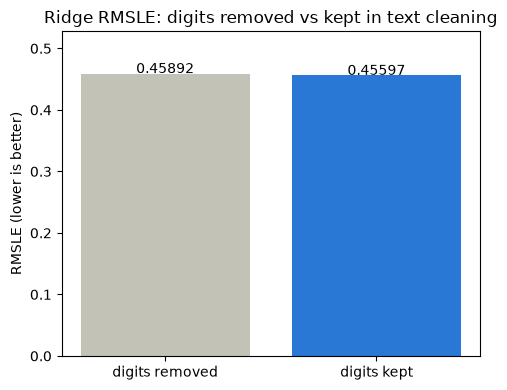

In [67]:
# 숫자 제거 vs 숫자 유지 - Ridge RMSLE 비교
# '숫자 유지'는 바로 위 Ridge 셀에서 방금 학습된 실제 ridge_rmsle 값 (현재 text_cleaning 기준).
# '숫자 제거'는 동일 파이프라인(train_test_split random_state=42, 동일 brand/category 전처리)에서
# text_cleaning 정규식만 [^a-z\s] (숫자 제거)로 되돌려 별도로 검증했던 결과값 (고정 기록값).
digit_removed_rmsle = 0.45892
digit_kept_rmsle = ridge_rmsle

comparison = pd.DataFrame({
    'version': ['digits removed', 'digits kept'],
    'ridge_rmsle': [digit_removed_rmsle, digit_kept_rmsle],
})
print(comparison.to_string(index=False))

diff = digit_kept_rmsle - digit_removed_rmsle
better = 'digits kept' if digit_kept_rmsle < digit_removed_rmsle else 'digits removed'
print(f'차이: {diff:+.5f}  ({better}가 더 좋음)')

plt.figure(figsize=(5, 4))
bars = plt.bar(comparison['version'], comparison['ridge_rmsle'], color=['#c3c2b7', '#2a78d6'])
plt.ylabel('RMSLE (lower is better)')
plt.title('Ridge RMSLE: digits removed vs kept in text cleaning')
for b in bars:
    plt.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.001, f'{b.get_height():.5f}', ha='center')
plt.ylim(0, max(comparison['ridge_rmsle']) * 1.15)
plt.tight_layout()
plt.show()

alpha=1    RMSLE=0.45597
alpha=2    RMSLE=0.45483
alpha=3    RMSLE=0.45447
alpha=4    RMSLE=0.45448
alpha=5    RMSLE=0.45468

best alpha = 3.0 (RMSLE 0.45447)


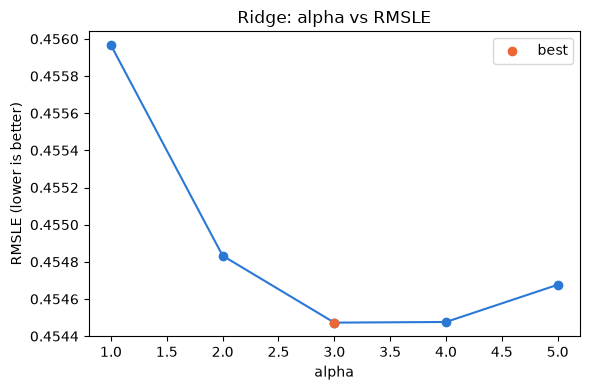

In [69]:
# Ridge alpha 값별 성능 비교 (1, 2, 3, 4, 5)
alphas = [1, 2, 3, 4, 5]
alpha_results = []

for a in alphas:
    r = Ridge(alpha=a)
    r.fit(X_train, y_train)
    pred = r.predict(X_test)
    rmsle = rmsle_on_log_scale(y_test, pred)
    alpha_results.append({'alpha': a, 'rmsle': rmsle})
    print(f'alpha={a:<4} RMSLE={rmsle:.5f}')

alpha_df = pd.DataFrame(alpha_results)
best_row = alpha_df.loc[alpha_df['rmsle'].idxmin()]
print(f"\nbest alpha = {best_row['alpha']} (RMSLE {best_row['rmsle']:.5f})")

plt.figure(figsize=(6, 4))
plt.plot(alpha_df['alpha'], alpha_df['rmsle'], marker='o', color='#2a78d6')
plt.scatter([best_row['alpha']], [best_row['rmsle']], color='#eb6834', zorder=5, label='best')
plt.xlabel('alpha')
plt.ylabel('RMSLE (lower is better)')
plt.title('Ridge: alpha vs RMSLE')
plt.legend()
plt.tight_layout()
plt.show()

In [57]:
# 본 모델: GBM 계열 (LightGBM)
import lightgbm as lgb

# 전체실행(Run All) 할 때마다 97분씩 기다리지 않도록 빠른 검증 모드 스위치.
# 최종 성능을 제대로 볼 때만 False로 바꿔서 2000라운드 풀로 돌릴 것 (그때는 다시 오래 걸림).
FAST_LGBM_CHECK = True
NUM_BOOST_ROUND = 150 if FAST_LGBM_CHECK else 2000
EARLY_STOPPING_ROUNDS = 30 if FAST_LGBM_CHECK else 50

lgb_train = lgb.Dataset(X_train, label=y_train)
lgb_valid = lgb.Dataset(X_test, label=y_test, reference=lgb_train)

lgb_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'learning_rate': 0.1,
    'num_leaves': 31,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'random_state': RANDOM_STATE,
    'verbose': -1,
}

gbm_model = lgb.train(
    lgb_params,
    lgb_train,
    num_boost_round=NUM_BOOST_ROUND,
    valid_sets=[lgb_train, lgb_valid],
    valid_names=['train', 'valid'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=EARLY_STOPPING_ROUNDS),
        lgb.log_evaluation(period=max(NUM_BOOST_ROUND // 10, 10)),
    ],
)

gbm_pred = gbm_model.predict(X_test, num_iteration=gbm_model.best_iteration)
gbm_rmsle = rmsle_on_log_scale(y_test, gbm_pred)

print(f'[LightGBM] RMSLE : {gbm_rmsle:.5f} (best_iteration={gbm_model.best_iteration}, FAST_LGBM_CHECK={FAST_LGBM_CHECK})')
if FAST_LGBM_CHECK:
    print('※ 빠른 검증 모드 - 라운드를 줄여서 돌린 결과라 최종 성능(2000라운드)보다 낮게 나올 수 있음')

Training until validation scores don't improve for 30 rounds
[15]	train's rmse: 0.631585	valid's rmse: 0.632052
[30]	train's rmse: 0.594521	valid's rmse: 0.595233
[45]	train's rmse: 0.571745	valid's rmse: 0.572691
[60]	train's rmse: 0.557302	valid's rmse: 0.558432
[75]	train's rmse: 0.5469	valid's rmse: 0.548273
[90]	train's rmse: 0.538852	valid's rmse: 0.540364
[105]	train's rmse: 0.532245	valid's rmse: 0.533934
[120]	train's rmse: 0.526844	valid's rmse: 0.528676
[135]	train's rmse: 0.52233	valid's rmse: 0.524288
[150]	train's rmse: 0.518315	valid's rmse: 0.520447
Did not meet early stopping. Best iteration is:
[150]	train's rmse: 0.518315	valid's rmse: 0.520447
[LightGBM] RMSLE : 0.52045 (best_iteration=150, FAST_LGBM_CHECK=True)
※ 빠른 검증 모드 - 라운드를 줄여서 돌린 결과라 최종 성능(2000라운드)보다 낮게 나올 수 있음


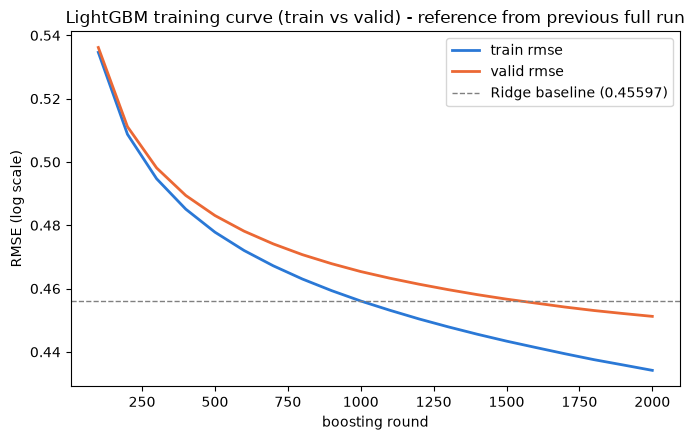

In [58]:
# LightGBM 학습 곡선 시각화
# 주의: 아래 수치는 예전 "숫자 제거 + 2000라운드 풀 학습" 때의 로그를 하드코딩한 것.
# FAST_LGBM_CHECK=True로 돌린 현재 결과와는 안 맞으니, 최종(2000라운드) 재학습 후에만 참고할 것.
rounds = list(range(100, 2001, 100))
train_rmse_log = [0.534645, 0.508757, 0.494704, 0.485094, 0.477825, 0.47203, 0.467199, 0.463014,
                   0.459355, 0.456071, 0.453145, 0.450405, 0.447908, 0.44557, 0.443396, 0.441387,
                   0.439415, 0.437539, 0.435863, 0.434161]
valid_rmse_log = [0.536182, 0.511156, 0.498119, 0.489417, 0.483081, 0.47814, 0.47412, 0.470715,
                   0.467869, 0.465379, 0.463272, 0.461383, 0.459661, 0.458082, 0.456664, 0.455416,
                   0.454169, 0.453068, 0.452115, 0.45122]

plt.figure(figsize=(7, 4.5))
plt.plot(rounds, train_rmse_log, label='train rmse', color='#2a78d6', linewidth=2)
plt.plot(rounds, valid_rmse_log, label='valid rmse', color='#eb6834', linewidth=2)
plt.axhline(ridge_rmsle, color='gray', linestyle='--', linewidth=1, label=f'Ridge baseline ({ridge_rmsle:.5f})')
plt.xlabel('boosting round')
plt.ylabel('RMSE (log scale)')
plt.title('LightGBM training curve (train vs valid) - reference from previous full run')
plt.legend()
plt.tight_layout()
plt.show()

In [59]:
# 베이스라인 vs GBM 성능 비교
improvement = (1 - gbm_rmsle / ridge_rmsle) * 100

print(f'Ridge baseline RMSLE : {ridge_rmsle:.5f}')
print(f'LightGBM RMSLE       : {gbm_rmsle:.5f}')
print(f'GBM 개선폭            : {ridge_rmsle - gbm_rmsle:.5f} ({improvement:.2f}% 개선)')

Ridge baseline RMSLE : 0.45597
LightGBM RMSLE       : 0.52045
GBM 개선폭            : -0.06448 (-14.14% 개선)


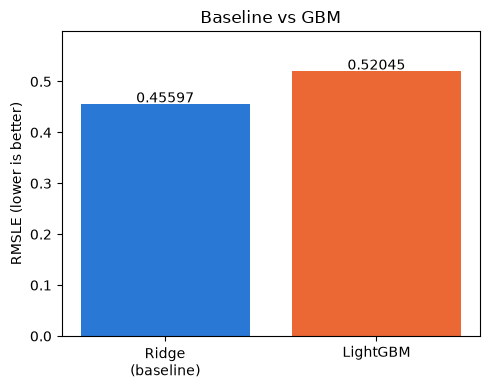

In [60]:
# 베이스라인 vs GBM 성능 비교 시각화
plt.figure(figsize=(5, 4))
bars = plt.bar(['Ridge\n(baseline)', 'LightGBM'], [ridge_rmsle, gbm_rmsle], color=['#2a78d6', '#eb6834'])
plt.ylabel('RMSLE (lower is better)')
plt.title('Baseline vs GBM')
for b in bars:
    plt.text(b.get_x()+b.get_width()/2, b.get_height()+0.003, f'{b.get_height():.5f}', ha='center')
plt.ylim(0, max(ridge_rmsle, gbm_rmsle)*1.15)
plt.tight_layout()
plt.show()

In [61]:
# LightGBM feature importance 확인 (해석/분석용)
feature_names = (
    list(ohe.get_feature_names_out(cat_cols))
    + numeric_cols
    + ['shipping']
    + [f'name__{f}' for f in name_vectorizer.get_feature_names_out()]
    + [f'desc__{f}' for f in desc_vectorizer.get_feature_names_out()]
)

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': gbm_model.feature_importance(importance_type='gain'),
}).sort_values('importance', ascending=False)

importance_df.head(20)

,feature,importance
5528,shipping,138811.512131
21141,name__lularoe,64850.772228
4634,cat_sub_Shoes,55831.982391
39381,desc__authentic,40093.997276
42107,desc__box,39917.951981
4659,cat_sub_Women's Handbags,39529.404640
4836,cat_sub2_Cell Phones & Smartphones,34705.387314
5527,item_condition_id,31091.640369
4191,brand_name_Unknown,28465.803894
10341,name__bundle,25714.462204


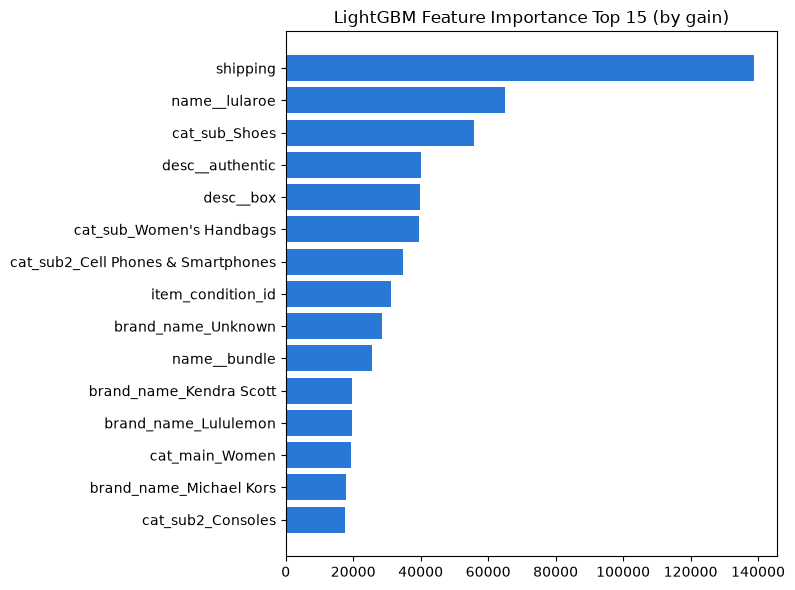

In [62]:
# feature importance 시각화 (top 15)
top_n = importance_df.head(15).iloc[::-1]  # barh는 아래부터 그려지므로 역순으로 뒤집어서 위쪽에 1위가 오게 함

plt.figure(figsize=(8, 6))
plt.barh(top_n['feature'], top_n['importance'], color='#2a78d6')
plt.title('LightGBM Feature Importance Top 15 (by gain)')
plt.tight_layout()
plt.show()

In [63]:
# 실제 가격 스케일로 복원해서 예측 결과 확인 (log1p -> expm1)
result_df = test_df[['name', 'item_condition_id', 'brand_name', 'shipping']].copy()
result_df['actual_price'] = np.expm1(y_test)
result_df['ridge_pred_price'] = np.expm1(ridge_pred)
result_df['gbm_pred_price'] = np.expm1(gbm_pred)

result_df.head(10)

,name,item_condition_id,brand_name,shipping,actual_price,ridge_pred_price,gbm_pred_price
0,lipsmakerqueen,1,Unknown,1,6.0,9.032641,10.278833
1,watch dogs xbox 360,1,Xbox,1,15.0,17.838048,17.508271
2,egyptian print high low cardigan,2,FOREVER 21,0,12.0,13.792058,12.387210
3,new kylie jenner lipkit maliboo,1,Kylie Cosmetics,0,13.0,19.929226,20.218130
4,titanfall 2,2,Xbox,0,29.0,19.490370,18.871903
5,high top sneakers 7c,3,Old Navy,0,8.0,10.931416,11.444947
6,grey boys petticoat outfit 9m,3,Carter's,1,6.0,6.365958,8.991471
7,crop top,3,Unknown,0,7.0,8.604083,11.136710
8,like new carhartt faded glory size 36,2,Carhartt,0,16.0,12.035412,19.122579
9,rae dunn spoon rest,1,Rae Dunn,0,17.0,20.077379,29.255139


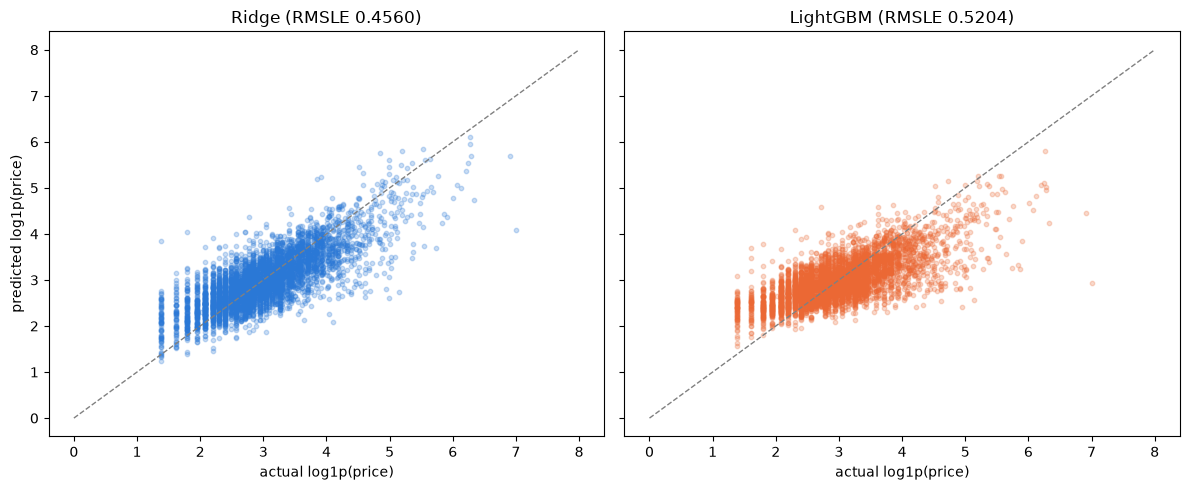

In [64]:
# 실제값 vs 예측값 산점도 (log1p 스케일 - RMSLE를 계산한 공간과 동일, test 5000건 샘플링)
sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(y_test), size=5000, replace=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

axes[0].scatter(y_test[sample_idx], ridge_pred[sample_idx], alpha=0.25, s=10, color='#2a78d6')
axes[0].plot([0, 8], [0, 8], color='gray', linestyle='--', linewidth=1)
axes[0].set_title(f'Ridge (RMSLE {ridge_rmsle:.4f})')
axes[0].set_xlabel('actual log1p(price)')
axes[0].set_ylabel('predicted log1p(price)')

axes[1].scatter(y_test[sample_idx], gbm_pred[sample_idx], alpha=0.25, s=10, color='#eb6834')
axes[1].plot([0, 8], [0, 8], color='gray', linestyle='--', linewidth=1)
axes[1].set_title(f'LightGBM (RMSLE {gbm_rmsle:.4f})')
axes[1].set_xlabel('actual log1p(price)')

plt.tight_layout()
plt.show()

In [65]:
# 최종 모델 저장 (전처리 아티팩트 + 학습된 모델을 함께 저장해야 실제 '가격 추천 시스템'으로 재사용 가능)
gbm_model.save_model('mercari_gbm_model.txt')

with open('mercari_ridge_model.pkl', 'wb') as f:
    pickle.dump(ridge, f)


def predict_price(raw_df, model=gbm_model, artifacts=pipeline_artifacts):
    """새로 들어온 원본 상품 데이터(raw_df)를 받아 가격을 예측해 반환한다."""
    X_new = preprocess_new_data(raw_df, artifacts)
    pred_log = model.predict(X_new, num_iteration=model.best_iteration)
    return np.expm1(pred_log)

            group  n_features  sum_abs_weight  mean_abs_weight
      description       50000     8617.940786         0.172359
             name       30000     5964.243977         0.198808
       brand_name        4536      887.078601         0.195564
         category         991      155.679069         0.157093
         shipping           1        0.185210         0.185210
item_condition_id           1        0.087229         0.087229


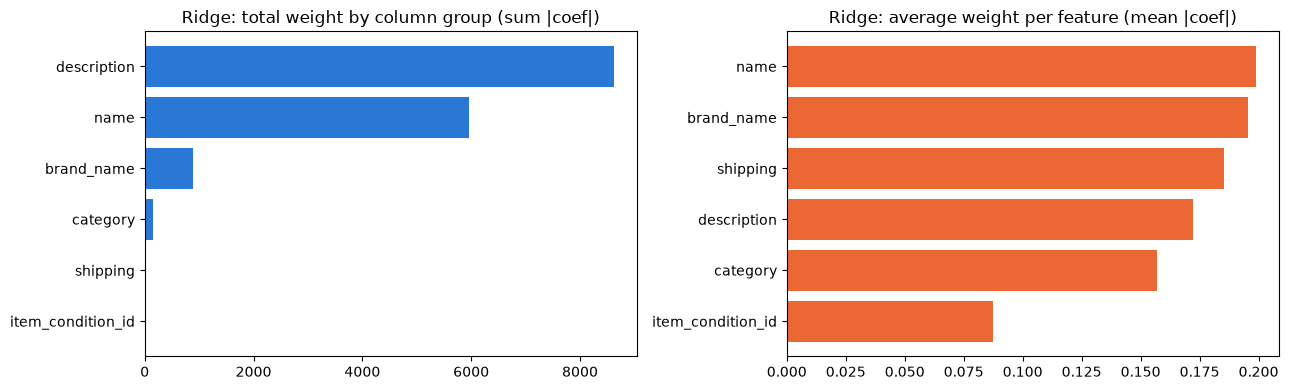

In [66]:
# Ridge 계수(coef_)를 6개 컬럼 그룹(brand_name / category / item_condition_id / shipping / name / description)으로
# 묶어서 그룹별 대표 가중치를 확인한다. X_train을 hstack한 순서(cat, num, ship, name, desc) 그대로 슬라이싱.

cat_lengths = [len(c) for c in ohe.categories_]  # cat_cols = ['brand_name','cat_main','cat_sub','cat_sub2'] 순서
n_brand = cat_lengths[0]
n_category = sum(cat_lengths[1:])  # cat_main + cat_sub + cat_sub2 를 'category' 하나로 묶음

offset = 0
brand_coef = ridge.coef_[offset:offset+n_brand]; offset += n_brand
category_coef = ridge.coef_[offset:offset+n_category]; offset += n_category
condition_coef = ridge.coef_[offset:offset+X_num_train.shape[1]]; offset += X_num_train.shape[1]
shipping_coef = ridge.coef_[offset:offset+1]; offset += 1
name_coef = ridge.coef_[offset:offset+X_name_train.shape[1]]; offset += X_name_train.shape[1]
desc_coef = ridge.coef_[offset:offset+X_desc_train.shape[1]]; offset += X_desc_train.shape[1]

assert offset == len(ridge.coef_), 'offset이 전체 계수 길이와 안 맞음 - 슬라이싱 순서 확인 필요'

groups = {
    'brand_name': brand_coef,
    'category': category_coef,
    'item_condition_id': condition_coef,
    'shipping': shipping_coef,
    'name': name_coef,
    'description': desc_coef,
}

weight_summary = pd.DataFrame({
    'group': list(groups.keys()),
    'n_features': [len(v) for v in groups.values()],
    'sum_abs_weight': [np.abs(v).sum() for v in groups.values()],
    'mean_abs_weight': [np.abs(v).mean() for v in groups.values()],
}).sort_values('sum_abs_weight', ascending=False)

print(weight_summary.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

order1 = weight_summary.sort_values('sum_abs_weight')
axes[0].barh(order1['group'], order1['sum_abs_weight'], color='#2a78d6')
axes[0].set_title('Ridge: total weight by column group (sum |coef|)')

order2 = weight_summary.sort_values('mean_abs_weight')
axes[1].barh(order2['group'], order2['mean_abs_weight'], color='#eb6834')
axes[1].set_title('Ridge: average weight per feature (mean |coef|)')

plt.tight_layout()
plt.show()